# 04 - Baseline por regras e CRF

Primeira comparacao sistematica. Duas abordagens, avaliadas contra o mesmo
conjunto de teste revisado manualmente:

1. **Regras**: o proprio pre-anotador do notebook 02, sem aprendizado.
2. **CRF**: campo aleatorio condicional sobre caracteristicas de token.

A avaliacao e estrita em nivel de span: inicio, fim e tag precisam coincidir.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import collections
import random

import pandas as pd

from src.dados import (
    carregar_produtos, titulos_unicos, marcas_do_catalogo,
    salvar_jsonl, carregar_jsonl, DIR_ANOT,
)

BASE = "cellphone"

from src.preanotacao import anotar_base, anotar_titulo, _regex_marcas
from src.avaliacao import para_bio, de_bio, avaliar, erros

In [2]:
caminho_teste = DIR_ANOT / f"{BASE}.ibyte.teste.jsonl"
assert caminho_teste.exists(), "rode o notebook 03 e faca a revisao manual antes"

teste = carregar_jsonl(caminho_teste)
treino = carregar_jsonl(DIR_ANOT / f"{BASE}.ibyte.treino_auto.jsonl")

print(f"treino (rotulo automatico): {len(treino)} titulos")
print(f"teste (revisado manualmente): {len(teste)} titulos")

treino (rotulo automatico): 983 titulos
teste (revisado manualmente): 49 titulos


## 1. Baseline: regras

Aplica o pre-anotador aos titulos do teste e compara com a referencia revisada.

In [3]:
produtos = titulos_unicos(carregar_produtos(BASE))
marcas = _regex_marcas(marcas_do_catalogo(produtos))

predicao_regras = [
    {"text": r["text"], "entities": anotar_titulo(r["text"], marcas)}
    for r in teste
]

resultado_regras = pd.DataFrame(avaliar(teste, predicao_regras))
resultado_regras

,tag,precisao,revocacao,f1,suporte
0,CAMERA,1.000000,1.000000,1.000000,18
1,CODIGO,1.000000,0.904762,0.950000,21
2,COMPATIBILIDADE,0.882353,0.882353,0.882353,17
3,COR,0.966667,0.783784,0.865672,37
4,MARCA,0.980000,0.960784,0.970297,51
5,MEMORIA,1.000000,1.000000,1.000000,31
6,MODELO,1.000000,0.685714,0.813559,35
7,POTENCIA,0.000000,0.000000,0.000000,1
8,RAM,1.000000,1.000000,1.000000,16
9,REDE,1.000000,1.000000,1.000000,15


## 2. CRF

O modelo aprende a partir do treino rotulado automaticamente. Ele nao tem acesso
aos dicionarios: precisa inferir os padroes pelas caracteristicas dos tokens.

In [4]:
def caracteristicas(tokens, i):
    token = tokens[i]
    f = {
        "vies": 1.0,
        "minusculo": token.lower(),
        "sufixo3": token[-3:],
        "sufixo2": token[-2:],
        "prefixo2": token[:2],
        "maiuscula_inicial": token[:1].isupper(),
        "tudo_maiusculo": token.isupper(),
        "tem_digito": any(c.isdigit() for c in token),
        "so_digito": token.isdigit(),
        "alfanumerico": any(c.isdigit() for c in token) and any(c.isalpha() for c in token),
        "tamanho": len(token),
        "posicao": i,
        "primeiro": i == 0,
        "ultimo": i == len(tokens) - 1,
    }
    if i > 0:
        f.update({"-1:minusculo": tokens[i - 1].lower(),
                  "-1:tem_digito": any(c.isdigit() for c in tokens[i - 1]),
                  "-1:maiuscula": tokens[i - 1][:1].isupper()})
    if i > 1:
        f["-2:minusculo"] = tokens[i - 2].lower()
    if i < len(tokens) - 1:
        f.update({"+1:minusculo": tokens[i + 1].lower(),
                  "+1:tem_digito": any(c.isdigit() for c in tokens[i + 1])})
    if i < len(tokens) - 2:
        f["+2:minusculo"] = tokens[i + 2].lower()
    return f


def vetorizar(registros):
    X, y = [], []
    for registro in registros:
        tokens, rotulos = para_bio(registro)
        X.append([caracteristicas(tokens, i) for i in range(len(tokens))])
        y.append(rotulos)
    return X, y

In [5]:
import sklearn_crfsuite

X_treino, y_treino = vetorizar(treino)
X_teste, y_teste = vetorizar(teste)

crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=200,
    all_possible_transitions=True,
)
crf.fit(X_treino, y_treino)
print(f"tokens de treino: {sum(len(x) for x in X_treino)}")
print(f"rotulos aprendidos: {len(crf.classes_)}")

tokens de treino: 15254
rotulos aprendidos: 25


In [6]:
previsto = crf.predict(X_teste)

predicao_crf = [
    {"text": r["text"], "entities": de_bio(r["text"], rotulos)}
    for r, rotulos in zip(teste, previsto)
]

resultado_crf = pd.DataFrame(avaliar(teste, predicao_crf))
resultado_crf

,tag,precisao,revocacao,f1,suporte
0,CAMERA,1.000000,1.000000,1.000000,18
1,CODIGO,1.000000,0.904762,0.950000,21
2,COMPATIBILIDADE,0.866667,0.764706,0.812500,17
3,COR,0.966667,0.783784,0.865672,37
4,MARCA,0.979592,0.941176,0.960000,51
5,MEMORIA,1.000000,0.935484,0.966667,31
6,MODELO,1.000000,0.685714,0.813559,35
7,POTENCIA,0.000000,0.000000,0.000000,1
8,RAM,1.000000,1.000000,1.000000,16
9,REDE,1.000000,1.000000,1.000000,15


## 3. Comparacao

In [7]:
comparacao = pd.merge(
    resultado_regras[["tag", "f1", "suporte"]].rename(columns={"f1": "regras"}),
    resultado_crf[["tag", "f1"]].rename(columns={"f1": "crf"}),
    on="tag", how="outer",
)
comparacao["diferenca"] = comparacao["crf"] - comparacao["regras"]
comparacao.sort_values("suporte", ascending=False)

,tag,regras,suporte,crf,diferenca
12,macro,0.869867,311,0.860410,-0.009457
13,micro,0.946488,311,0.937605,-0.008883
4,MARCA,0.970297,51,0.960000,-0.010297
11,TIPO,1.000000,45,1.000000,0.000000
3,COR,0.865672,37,0.865672,0.000000
6,MODELO,0.813559,35,0.813559,0.000000
5,MEMORIA,1.000000,31,0.966667,-0.033333
10,TELA,0.956522,24,0.956522,0.000000
1,CODIGO,0.950000,21,0.950000,0.000000
0,CAMERA,1.000000,18,1.000000,0.000000


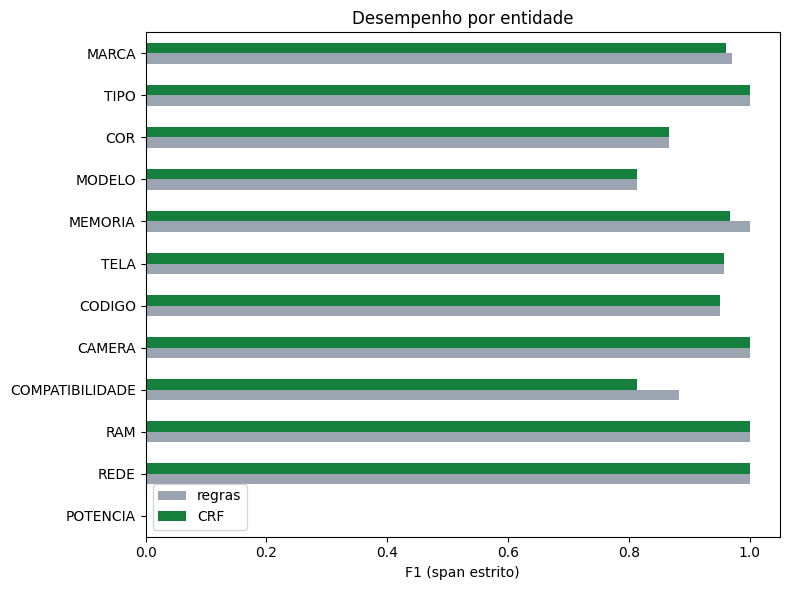

In [8]:
import matplotlib.pyplot as plt

por_tag = comparacao[~comparacao["tag"].isin(["micro", "macro"])].sort_values("suporte")
eixo = por_tag.plot.barh(x="tag", y=["regras", "crf"], figsize=(8, 6),
                         color=["#9aa5b1", "#15803d"])
eixo.set_xlabel("F1 (span estrito)")
eixo.set_ylabel("")
eixo.set_title("Desempenho por entidade")
eixo.legend(["regras", "CRF"])
plt.tight_layout()
plt.show()

## 4. Curva de aprendizado

Mostra quanto o CRF ganha com mais dados de treino. Se a curva estiver plana no
fim, anotar mais titulos traria pouco retorno; se ainda estiver subindo, o
tamanho da base e o fator limitante.

   50 titulos -> F1 0.808
  100 titulos -> F1 0.882
  200 titulos -> F1 0.905
  400 titulos -> F1 0.927
  600 titulos -> F1 0.936
  983 titulos -> F1 0.938


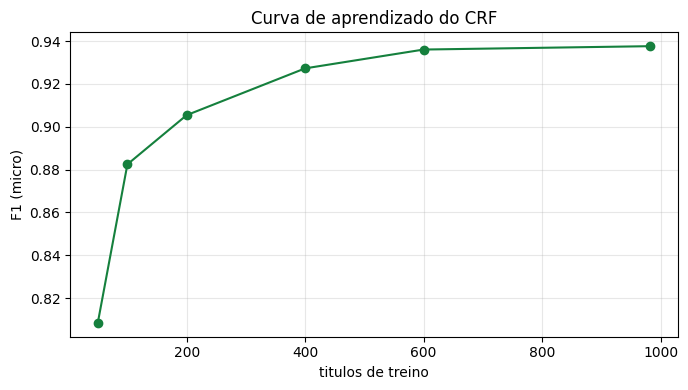

In [11]:
treino_embaralhado = treino[:]
random.Random(42).shuffle(treino_embaralhado)

tamanhos = [50, 100, 200, 400, 600, len(treino)]
curva = []

for n in tamanhos:
    if n > len(treino):
        continue
    parcial = treino_embaralhado[:n]
    Xp, yp = vetorizar(parcial)
    modelo = sklearn_crfsuite.CRF(algorithm="lbfgs", c1=0.1, c2=0.1,
                                  max_iterations=200, all_possible_transitions=True)
    modelo.fit(Xp, yp)
    pred = [{"text": r["text"], "entities": de_bio(r["text"], rot)}
            for r, rot in zip(teste, modelo.predict(X_teste))]
    micro = [l for l in avaliar(teste, pred) if l["tag"] == "micro"][0]
    curva.append({"titulos": n, "f1": micro["f1"]})
    print(f"{n:5} titulos -> F1 {micro['f1']:.3f}")

pd.DataFrame(curva).plot(x="titulos", y="f1", marker="o", figsize=(7, 4),
                         legend=False, color="#15803d")
plt.ylabel("F1 (micro)")
plt.xlabel("titulos de treino")
plt.title("Curva de aprendizado do CRF")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

## 5. Analise dos erros

Os spans divergentes explicam onde cada abordagem falha.

In [10]:
pd.DataFrame(erros(teste, predicao_crf, limite=20))

,titulo,trecho,esperado,obtido,tipo
0,Smartphone Motorola Moto Edge 30 Fusion 256GB ...,Fusion,MODELO,-,nao encontrado
1,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Flip,MODELO,-,nao encontrado
2,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Vita,MODELO,-,nao encontrado
3,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Lite,MODELO,-,nao encontrado
4,Combo Connect - Celular Multilaser Up Play Dua...,P9076K,MODELO,-,nao encontrado
5,iPhone 13 Apple Starlight 512GB Desbloqueado -...,Starlight,COR,-,nao encontrado
6,Smartphone F Pro 2 32 GB + 1GB RAM 4G Tela LDC...,F,MODELO,-,nao encontrado
7,Smartphone F Pro 2 32 GB + 1GB RAM 4G Tela LDC...,Pro,MODELO,-,nao encontrado
8,Smartphone F Pro 2 32 GB + 1GB RAM 4G Tela LDC...,32 GB,MEMORIA,-,nao encontrado
9,Smartphone F Pro 2 32 GB + 1GB RAM 4G Tela LDC...,Tela LDC,TELA,-,nao encontrado


## 6. Observacoes

**O CRF nao superou o baseline.** Micro F1 0,938 contra 0,946 das regras, com
empate exato em oito das doze entidades, incluindo MODELO (0,8136 nos dois).

**Teto da supervisao fraca.** O CRF foi treinado com rotulos produzidos pelas
proprias regras. Casos que as regras nao reconhecem (`Multilaser G Pro`,
`LG K8 Plus`) nunca aparecem rotulados no treino, e o modelo nao tem como
aprende-los. O desempenho fica limitado pelo do rotulador.

**Onde o CRF perdeu:** COMPATIBILIDADE (-0,070) e MEMORIA (-0,033). A regra de
compatibilidade depende do tipo do produto, informacao global do titulo que as
features locais de token capturam mal.

**A curva de aprendizado saturou.** De 0,808 com 50 titulos a 0,938 com 983,
mas o ganho entre 600 e 983 foi de apenas 0,002. O fator limitante nao e o
volume de dados: e a qualidade do rotulo.

**Cuidado metodologico.** Na primeira execucao os recortes seguiam a ordem do
arquivo, agrupada por categoria, o que produzia um salto artificial de 0,077
entre 400 e 600 titulos. Com embaralhamento previo (semente fixa) o salto cai
para 0,009. O efeito era composicao da amostra, nao aprendizado.

**Consequencia.** Para superar o baseline e preciso quebrar a dependencia do
rotulo automatico: treinar com anotacao revisada manualmente, ou usar um modelo
com conhecimento externo ao dataset.